[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/cdg-ime/blob/main/PreProcessamento.ipynb)

# Ciência de Dados Geoespaciais - Pré-Processamento

**Maj Diego - 2° Semestre / 2026**

**Objetivos**

1. Identificar problemas comuns nos dados vetoriais;
2. Identificar problemas comuns nos dados raster;
3. Aplicar métodos de remoção de outliers na limpeza de dados;
4. Aplicar métodos de completamento de dados.


## O Contexto

Após a **prospecção**, raramente os dados chegam prontos para análise. Na prática, estima-se que [60–80% do tempo de um cientista de dados é gasto limpando e preparando os dados (pré-processamento)](https://www.linkedin.com/pulse/quanto-tempo-um-analista-de-dados-passa-realmente-rafael-pacheco-4oj5f/).

Prospecção $\rightarrow$ **Pré-Processamento** $\rightarrow$ Exploração $\rightarrow$ Modelagem $\rightarrow$ Comunicação 

## 1. Identificar problemas comuns nos dados vetoriais

**Dataset de referência**: Vetorial sintético (`postos_pluviometricos.gpkg`) do estado do Rio de Janeiro, propositalmente com problemas comuns do mundo real.

In [36]:
import pandas as pd
import geopandas as gpd

# Dataset sintético: postos pluviométricos do RJ
dados_brutos = {
    'id'           : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'nome'         : ['Posto A', 'Posto B', 'Posto C', 'Posto D', 'posto a',
                       'Posto F', 'Posto G', 'Posto H', 'Posto I', 'Posto J', 
                       'Posto K', 'Posto B'],                                        # Posto duplicado
    'municipio'    : ['Niterói', 'Rio de Janeiro', 'Petrópolis', 'Angra dos Reis',
                       'Niterói', 'Volta Redonda', None, 'Campos', 'Resende', 
                       'Macaé', 'Cabo Frio', 'Rio de Janeiro'],                      # Cidade desconhecida
    'latitude'     : [-22.88, -22.90, -22.51, -23.01, -22.88, -22.52,
                      -22.75, -21.75, -22.47, -22.38, -22.88, -22.90],
    'longitude'    : [-43.10, -43.17, -43.18, -44.32, -43.10, -44.08,
                      -250.0, -41.33, -44.45, -41.79, -42.02, -43.17],   # longitude inválida
    'precip_jan_mm': [120.5, None, 98.3, 135.0, 120.5, 88.7, 
                       77.2, 200.0, 61.4, 110.2, 95.8, 135.0],         # precipitação desconhecida
    'precip_fev_mm': [110.2, 142.1, 91.7, 88.0, 110.2, 80.1,
                       70.5, 9999.0, 58.2, 105.3, 91.1, 142.1],         # 9999 = valor sentinela
    'ativo'        : [True, True, True, True, True, True, True, False, True,
                      True, True, True]
}

df = pd.DataFrame(dados_brutos)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
gdf.to_file("postos_pluviometricos.gpkg", driver="GPKG")

df.head(12)[["nome", "municipio", "latitude", "longitude", "precip_jan_mm", "precip_fev_mm", "ativo"]]

,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,ativo
0,Posto A,Niterói,-22.88,-43.10,120.5,110.2,True
1,Posto B,Rio de Janeiro,-22.90,-43.17,NaN,142.1,True
2,Posto C,Petrópolis,-22.51,-43.18,98.3,91.7,True
3,Posto D,Angra dos Reis,-23.01,-44.32,135.0,88.0,True
4,posto a,Niterói,-22.88,-43.10,120.5,110.2,True
5,Posto F,Volta Redonda,-22.52,-44.08,88.7,80.1,True
6,Posto G,None,-22.75,-250.00,77.2,70.5,True
7,Posto H,Campos,-21.75,-41.33,200.0,9999.0,False
8,Posto I,Resende,-22.47,-44.45,61.4,58.2,True
9,Posto J,Macaé,-22.38,-41.79,110.2,105.3,True


### **1.1 Categorias de problemas nos dados vetoriais**

| Categoria | Problema | Exemplo no dataset |
|-----------|----------|--------------------|
| **Completude** | Valores ausentes (`NaN`) | `municipio` do Posto G|
| **Consistência** | Duplicatas | Posto B (mesmas coordendas) |
| **Validade** | Valores fora do domínio¹ | `longitude = -250.0` (impossível) |
| **Validade** | Valores sentinela | `precip_fev_mm = 9999` (código de erro legado) |
| **Relevância** | Registros inativos | `ativo = False` no Posto H |
| **Padronização** | Inconsistência de grafia | `'posto a'` vs `'Posto A'` |
| **Outliers** | Valores extremos² | - |

(1): Inclui-se a **validade geométrica:** análise da estruturas geométricas fora do domínio, ou seja, das regras do contexto semântico em que o dado se encontra. <br>
**Por exemplo:** Autointerseções, nós duplicados, sobreposições entre poligonos, lacunas entre polígonos, etc ...

(2): A ser tratado em objetivo à parte

### **1.2 Ferramentas de diagnóstico**

[Data type objects (dtype)](https://numpy.org/doc/stable/reference/arrays.dtypes.html): Descreve como os bytes correspodentes ao dado devem ser interpretados. 

In [37]:
# Tipos de dados
print("=" * 50)
print("TIPOS DE DADOS")
print("=" * 50)
print(df.dtypes)


TIPOS DE DADOS
id                 int64
nome              object
municipio         object
latitude         float64
longitude        float64
precip_jan_mm    float64
precip_fev_mm    float64
ativo               bool
dtype: object


### **1.2 Ferramentas de diagnóstico**

[pandas.DataFrame.describe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html): Gera estatísticas descritivas que incluem o centro tendência, dispersão e formato de um Distribuição do conjunto de dados, excluindo valores `NaN`.

In [38]:
# Visão geral
print("\n" + "=" * 50)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 50)
df.describe()


ESTATÍSTICAS DESCRITIVAS


,id,latitude,longitude,precip_jan_mm,precip_fev_mm
count,12.000000,12.000000,12.000000,11.000000,12.000000
mean,5.500000,-22.652500,-60.309167,112.963636,924.041667
std,3.605551,0.353557,59.744949,37.018840,2857.983262
min,0.000000,-23.010000,-250.000000,61.400000,58.200000
25%,2.750000,-22.885000,-44.140000,92.250000,86.025000
50%,5.500000,-22.815000,-43.170000,110.200000,98.500000
75%,8.250000,-22.500000,-42.830000,127.750000,118.175000
max,11.000000,-21.750000,-41.330000,200.000000,9999.000000


### **1.2 Ferramentas de diagnóstico**

[ogrinfo](https://gdal.org/en/stable/programs/ogrinfo.html): Lista informações sobre uma fonte de dados suportada pela OGR. Com instruções SQL, também é possível editar dados.

In [ ]:
# ogrinfo
qgis_bin_path = 'C:/Program Files/QGIS 3.44.11/bin/' # ajustar 
!"{qgis_bin_path}ogrinfo.exe" -so postos_pluviometricos.gpkg postos_pluviometricos

INFO: Open of `postos_pluviometricos.gpkg'
      using driver `GPKG' successful.

Layer name: postos_pluviometricos
Geometry: Point
Feature Count: 12
Extent: (-250.000000, -23.010000) - (-41.330000, -21.750000)
Layer SRS WKT:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
          

### **1.3 Categoria completude**

In [40]:
# Valores ausentes
ausentes = df.isnull().sum()
pct = (ausentes / len(df) * 100).round(1)

auditoria = pd.DataFrame({
    'Nulos'     : ausentes,
    'Percentual': pct
}).query('Nulos > 0')

print("Colunas com valores ausentes:")
print(auditoria)

Colunas com valores ausentes:
               Nulos  Percentual
municipio          1         8.3
precip_jan_mm      1         8.3


### **1.4 Categoria consistência**

In [41]:
# Verificação de duplicatas
print("Duplicatas por coordenada:")
print(df[df.duplicated(subset=['latitude','longitude'], keep=False)]
      [['id','nome','latitude','longitude']])

Duplicatas por coordenada:
    id     nome  latitude  longitude
0    0  Posto A    -22.88     -43.10
1    1  Posto B    -22.90     -43.17
4    4  posto a    -22.88     -43.10
11  11  Posto B    -22.90     -43.17


### **1.5 Categoria validade**

In [42]:
# Verificação de domínio (regras de negócio)
print("Coordenadas fora do domínio válido (lat: -90/90, lon: -180/180):")
invalidos_coord = df[
    (df['latitude'].abs()  > 90)  |
    (df['longitude'].abs() > 180)
]
print(invalidos_coord[['id','nome','latitude','longitude']])

print("\nValores sentinela (9999):")
print(df[df[['precip_jan_mm','precip_fev_mm']].ge(9000).any(axis=1)]
      [['id','nome','precip_jan_mm','precip_fev_mm']])

Coordenadas fora do domínio válido (lat: -90/90, lon: -180/180):
   id     nome  latitude  longitude
6   6  Posto G    -22.75     -250.0

Valores sentinela (9999):
   id     nome  precip_jan_mm  precip_fev_mm
7   7  Posto H          200.0         9999.0


### **1.6 Categoria relevância**

In [43]:
# Verificação de valores sem confiabilidade (ex: estações inativas)
print("Estações inativas:")
print(df[df.ativo == False][['id','nome','latitude','longitude', 'ativo']])

Estações inativas:
   id     nome  latitude  longitude  ativo
7   7  Posto H    -21.75     -41.33  False


### **1.7 Categoria padronização**

In [44]:
# Verificação de erros de inserção de dados textuais (falta de padronização)
show_cols = ['id','nome','latitude','longitude', 'ativo']
print("Nomes fora do padrão:")
print(df[~df['nome'].str.contains(r'Posto [A-Z\s]', regex=True)][show_cols])

Nomes fora do padrão:
   id     nome  latitude  longitude  ativo
4   4  posto a    -22.88      -43.1   True


### **1.8 Visualização dos problemas (big picture)**

Vamos criar uma imagem (matriz) onde os valores representam o problema do dado.

**1º Passo**: O formato da tabela é o formato da imagem

In [45]:
nulos = df.isnull()
nulos

,id,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,ativo
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False
6,False,False,True,False,False,False,False,False
7,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False


**2º Passo**: converter de booleano para inteiro e definir valor=1 caso nulo

In [46]:
nulos = nulos.values.astype(int)
nulos

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**3º Passo**: definir valor=2 caso duplicatas

In [47]:
import numpy as np

dup_df = df[df.duplicated(subset=['latitude','longitude'], keep=False)].copy()
grupos = list(dup_df.groupby(['latitude', 'longitude'])
              .apply(lambda g: list(g.index), include_groups=False))
# grupos = [[1, 11], [0, 4]]

original, repetidos = [el[0] for el in grupos], [el[1:] for el in grupos]

duplicatas = np.zeros(nulos.shape, dtype=int)
duplicatas[repetidos] = 2
duplicatas

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 2, 2]])

**4º Passo**: definir valor=3 caso inválido

In [48]:
# Criar DataFrame booleano: True onde a condição é satisfeita, False nos demais
df_bool = pd.DataFrame(False, index=df.index, columns=df.columns)

# Coordenadas inválidas
condicao = df['latitude'].abs()  > 90
df_bool.loc[condicao, ['latitude']] = True
condicao = df['longitude'].abs() > 180
df_bool.loc[condicao, ['longitude']] = True

# Valores sentinela (9999)
condicao = df[['precip_jan_mm']].ge(9000).any(axis=1)
df_bool.loc[condicao, ['precip_jan_mm']] = True
condicao = df[['precip_fev_mm']].ge(9000).any(axis=1)
df_bool.loc[condicao, ['precip_fev_mm']] = True

invalidos = 3 * df_bool.values.astype(int)
invalidos

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 3, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**5º Passo**: definir valor=4 caso irrelevante

In [49]:
# Criar DataFrame booleano: True onde a condição é satisfeita, False nos demais
df_bool = pd.DataFrame(False, index=df.index, columns=df.columns)

# Postos inativos
condicao = df['ativo'] == False
df_bool.loc[condicao, ['ativo']] = True

irrelevantes = 4 * df_bool.values.astype(int)
irrelevantes

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 4],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**6º Passo**: definir valor=5 caso despadronizado

In [50]:
# Criar DataFrame booleano: True onde a condição é satisfeita, False nos demais
df_bool = pd.DataFrame(False, index=df.index, columns=df.columns)

# Nome com a a letra não maiúscuala
condicao = ~df['nome'].str.contains(r'Posto [A-Z\s]', regex=True)
df_bool.loc[condicao, ['nome']] = True

despadronizado = 5 * df_bool.values.astype(int)
despadronizado

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 5, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

**7º Passo**: Juntar tudo

In [51]:
# Sobrepor matrizes: máximo em cada posição (prioridade de problema)
mascara = np.maximum.reduce([nulos, duplicatas, invalidos, irrelevantes, despadronizado])
mascara

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [2, 5, 2, 2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 3, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 3, 4],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 2, 2]])

**8º Passo**: Planejar as cores

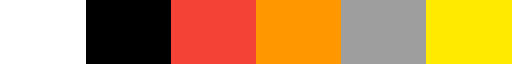

In [52]:
import matplotlib.colors as mcolors

N_cores = mascara.max()+1
colors = {
    "Sem problemas": "#ffffff",      # Branco - nenhum problema
    "Nulos": "#000000",              # Preto - dados faltando (recuperáveis)
    "Duplicatas": "#f44336",         # Vermelho vivo - erro crítico de integridade
    "Inválidos": "#ff9800",          # Laranja - aviso, fora de domínio
    "Irrelevantes": "#9e9e9e",       # Cinza médio - sem relevância
    "Despadronizados": "#ffea00"     # Amarelo - atenção, inconsistência
}
cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", 
                                                 list(colors.values()), 
                                                 N=N_cores)
cmap

**9º Passo**: Plot com mapa de cores

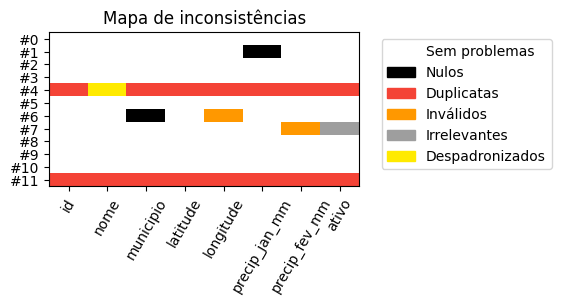

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 2))
ax.imshow(mascara, aspect='auto', cmap=cmap)
ax.set_yticks(range(len(df)))
ax.set_yticklabels([f"#{i}" for i in df['id']])
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=60)
ax.set_title("Mapa de inconsistências")
plt.legend(handles=[plt.Rectangle((0,0),1,1, color=colors[cat]) for cat in colors], 
           labels=list(colors.keys()), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **1.9 Validação geométrica**

<img src="media/imgs/geometry_checker_scheme.png" width=600>

Verificações suportdas pelo plugin do QGIS [Verificador de Geometria](https://docs.qgis.org/3.44/pt_BR/docs/user_manual/plugins/core_plugins/plugins_geometry_checker.html)

### **1.9 A validação geométrica**

A validação geométrica limpa os dados fora das regras topológicas do contexto. Imagine os seguintes problemas:

| Validação            | Tipo           | O que detecta | Possível aplicação          |
| -------------------------------- | -------------- | --------------| ---------------------------|
| **Self-intersection** | Linha/Polígono | Geometria cruza a si mesma                 | Correção de Limites administrativos     |
| **Duplicate nodes**  | Linha/Polígono | Vértices consecutivos na mesma posição      | Otimização dos algoritimos subsequentes |
| **Duplicate geommetries**  | Todos    | Geometrias na mesma posição                 | Otimização dos algoritimos subsequentes |
| **Spike**            | Linha/Polígono | Pontas estreitas geradas por erro de edição | Limpeza cartográfica                         |
| **Small area / Sliver** | Polígono    | Polígonos muito pequenos e indesejados      | Limpeza cartográfica                         |


### **1.9 A validação geométrica**

Imagine os seguintes problemas:

| Validação            | Tipo           | O que detecta | Possível aplicação          |
| -------------------------------- | -------------- | --------------| ---------------------------|
| **Gap**              | Polígono       | Lacunas entre polígonos adjacentes          | Cobertura contínua (cadastro, zoneamento)    |
| **Overlap**          | Polígono       | Sobreposição entre feições                  | Correção de Limites administrativos      |
| **Multipart geometry** | Todos        | Feição composta por partes desconectadas    | Quando apenas feições simples são permitidas |
| **Line overlap**     | Linha          | Trechos de linhas sobrepostos               | Redes lineares e limites                     |

### **1.10 Ferramentas de validação geométrica**

**qgis_process native:checkgeometry** 

```
qgis_bin_path = 'C:/Program Files/QGIS 3.44.11/bin'
!"{qgis_bin_path}qgis_process-qgis-ltr.bat" list
```

```
...
QGIS (native c++)
...
	native:checkgeometryangle			Small angles
	native:checkgeometryarea			Small polygons
	native:checkgeometrycontained			Features inside polygon
	native:checkgeometrydangle			Dangle-end lines
	native:checkgeometrydegeneratepolygon		Degenerate polygons
	native:checkgeometryduplicate			Duplicated geometries
	native:checkgeometryduplicatenodes		Duplicated vertices
	native:checkgeometryfollowboundaries		Polygons exceeding boundaries
	native:checkgeometrygap				Small gaps
	native:checkgeometryhole			Holes
	native:checkgeometrylineintersection		Lines intersecting each other
	native:checkgeometrylinelayerintersection	Lines intersecting other layer
	native:checkgeometrymissingvertex		Missing vertices along borders
	native:checkgeometrymultipart			Strictly multipart
	native:checkgeometryoverlap			Overlaps
	native:checkgeometrypointcoveredbyline		Points outside lines
	native:checkgeometrypointinpolygon		Points outside polygons
	native:checkgeometrysegmentlength		Small segments
	native:checkgeometryselfcontact			Self-contacts
	native:checkgeometryselfintersection		Self-intersections
	native:checkgeometrysliverpolygon		Sliver polygons
	native:checkvalidity				Check validity
...
```

### **1.10 Ferramentas de validação geométrica**

**Exemplo: Verificação de geometrias duplicadas** 

<img src="media/imgs/geometry_checker_dialog.png" width=700>

Acesso ao Plugin do QGIS [Verificador de Geometria](https://docs.qgis.org/3.44/pt_BR/docs/user_manual/plugins/core_plugins/plugins_geometry_checker.html) via GUI

### **1.10 Ferramentas de validação geométrica**

**Exemplo: Verificação de geometrias duplicadas** 

In [ ]:
!"{qgis_bin_path}qgis_process-qgis-ltr.bat" list

Available algorithms

QGIS (3D)
	3d:tessellate	Tessellate

GDAL
	gdal:aspect	Aspect
	gdal:assignprojection	Assign projection
	gdal:buffervectors	Buffer vectors
	gdal:buildvirtualraster	Build virtual raster
	gdal:buildvirtualvector	Build virtual vector
	gdal:cliprasterbyextent	Clip raster by extent
	gdal:cliprasterbymasklayer	Clip raster by mask layer
	gdal:clipvectorbyextent	Clip vector by extent
	gdal:clipvectorbypolygon	Clip vector by mask layer
	gdal:colorrelief	Color relief
	gdal:contour	Contour
	gdal:contour_polygon	Contour Polygons
	gdal:convertformat	Convert format
	gdal:dissolve	Dissolve
	gdal:executesql	Execute SQL
	gdal:extractprojection	Extract projection
	gdal:fillnodata	Fill NoData
	gdal:gdal2tiles	gdal2tiles
	gdal:gdal2xyz	gdal2xyz
	gdal:gdalinfo	Raster information
	gdal:gridaverage	Grid (Moving average)
	gdal:griddatametrics	Grid (Data metrics)
	gdal:gridinversedistance	Grid (Inverse distance to a power)
	gdal:gridinversedistancenearestneighbor	Grid (IDW with nearest nei

In [ ]:
!"{qgis_bin_path}qgis_process-qgis-ltr.bat" help native:checkgeometryduplicate

Algorithm native:checkgeometryduplicate not found!


### **1.10 Ferramentas de validação geométrica**

**Exemplo: Verificação de geometrias duplicadas** 

In [ ]:
# Evitar erros de GUI
import os
os.environ['QT_QPA_PLATFORM'] = 'offscreen'  # Evitar erros de GUI

# Cria um projeto QGIS temporário para o processamento.
# requisito do native:checkgeometryduplicate
with open("temp.qgs", "w") as f:
    f.write(f"""<!DOCTYPE qgis PUBLIC 'http://mrcc.com/qgis.dtd' 'SYSTEM'>
<qgis version="3.44"/>""")

# Verificação de geometrias duplicadas
!"{qgis_bin_path}qgis_process-qgis-ltr.bat" run native:checkgeometryduplicate \
  --INPUT="postos_pluviometricos.gpkg|layername=postos_pluviometricos" \
  --UNIQUE_ID=id \
  --ERRORS=erros_geometrias_duplicadas.gpkg \
  --PROJECT_PATH=temp.qgs


----------------
Inputs
----------------

ERRORS:	erros_geometrias_duplicadas.gpkg
INPUT:	postos_pluviometricos.gpkg|layername=postos_pluviometricos
UNIQUE_ID:	id


0...10...20...30.Preparing features�
..40...50...60..Collecting errors�
.70...Errors collected successfully.
80...90...100 - done.
Exporting errors�

----------------
Results
----------------

ERRORS:	erros_geometrias_duplicadas.gpkg


## 2. Identificar problemas comuns nos dados raster

### **2.1 Categorias de problemas nos dados raster**

| Categoria              | Problema                             | Consequência                                 |
| ---------------------- | ------------------------------------ | -------------------------------------------- |
| **SRC / CRS**          | CRS ausente ou incorreto             | Camadas não se alinham, erros de localização |
| **NoData**             | Valor NoData não definido ou coincide com valor real | Pixels inválidos entram nos cálculos |
| **Tipo de dado**       | Conversão Float → Integer            | Perda de precisão                            |
| **Metadados**          | Metadados ausentes ou incorretos     | Perda de informação e possivelmente de continuidade de processamento |
| **Compressão**         | Compressão com perdas                | Artefatos e degradação da qualidade          |
| **Resolução**          | Pixels com tamanhos diferentes       | Comparações e operações inconsistentes       |
| **Histograma**         | Outliers extremos                    | Contraste ruim e visualização inadequada     |


### **2.2 Categoria SRC e metadados**

**Dataset de referência**: Raster hyper-espectral do Jardim Botânico propositalmente e uma versão processada com problemas comuns do mundo real.

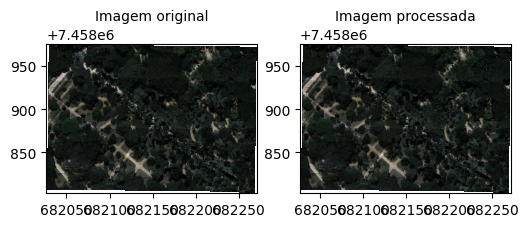

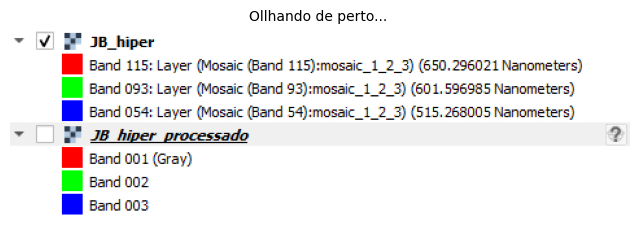

In [ ]:
import os
import gdown
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

if not os.path.exists("./JB_hiper.tif"):
    gdown.download( id= "1G7tuNW-r0uxZ25OR66MZ9su4fMk8cGKW", output="./JB_hiper.tif", quiet=True)

# qgis_bin_path = 'C:/Program Files/QGIS 3.40.4/bin' # 'ajustar
# !"{qgis_bin_path}gdalinfo.exe" JB_hiper.tif

src = rasterio.open('JB_hiper.tif')
# TODO: processamento
processed_data = src.read() 
rgb_src = src.read([115, 93, 54])

with rasterio.open('JB_hiper_processado.tif', 
                   'w', 
                   driver='GTiff', 
                   # crs=src.crs, # bug embutido
                   height=src.height, 
                   width=src.width,
                   nodata=-9999, #src.nodata, # bug embutido
                   count=src.count, 
                   dtype=src.read().dtype, 
                   transform=src.transform
                   ) as dst:
    
    dst.write(processed_data)

fig, ax = plt.subplots(1, 2 ,figsize=(6,6))

processada = rasterio.open('JB_hiper_processado.tif')
rgb_processada = processada.read([115, 93, 54])
ax[0].set_title("Imagem original", fontsize=10)
ax[1].set_title("Imagem processada", fontsize=10)
show(rgb_src, ax=ax[0], transform=src.transform) 
show(rgb_processada, ax=ax[1], transform=processada.transform) 
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("Ollhando de perto... ", fontsize=10)
ax.imshow(plt.imread("media/imgs/camadas.png"))

ax.set_axis_off()
plt.show()

### **2.2 Categoria SRC e metadados**

In [ ]:
!"{qgis_bin_path}gdalinfo.exe" JB_hiper.tif

Driver: GTiff/GeoTIFF
Files: JB_hiper.tif
Size is 613, 434
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 23S",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4326]],
    CONVERSION["UTM zone 23S",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-45,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
        PARAMETE

In [ ]:
!"{qgis_bin_path}gdalinfo.exe" JB_hiper_processado.tif

Driver: GTiff/GeoTIFF
Files: JB_hiper_processado.tif
Size is 613, 434
Origin = (682026.399999982211739,7458976.000003093853593)
Pixel Size = (0.399999999999990,-0.400000000000166)
Image Structure Metadata:
  INTERLEAVE=PIXEL
Corner Coordinates:
Upper Left  (  682026.400, 7458976.000) 
Lower Left  (  682026.400, 7458802.400) 
Upper Right (  682271.600, 7458976.000) 
Lower Right (  682271.600, 7458802.400) 
Center      (  682149.000, 7458889.200) 
Band 1 Block=613x1 Type=Float32, ColorInterp=Gray
  NoData Value=-9999
Band 2 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 3 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 4 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 5 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 6 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 7 Block=613x1 Type=Float32, ColorInterp=Undefined
  NoData Value=-9999
Band 8 Block=613x1 Type

### **2.2 Categoria SRC e metadados**

Se o usuário ainda possui o raster original, pode-se **transplantar os metadados raster**:

In [51]:
# O dado matricial em si vem do arquivo defeituso em metadados
processado = rasterio.open('JB_hiper_processado.tif')
data = processado.read()

# Os metadados vem do arquivo original não processado
src = rasterio.open('JB_hiper.tif')

with rasterio.open("JB_hiper_processado2.tif", "w", **src.profile.copy()) as dst:
    #  Write the image data
    dst.write(data)
    
    # Copy file-level metadata tags
    dst.update_tags(**src.tags())
        
    # Copy band-level descriptions (names)
    for band_idx, desc in enumerate(src.descriptions, start=1):
        dst.set_band_description(band_idx, desc.split("mosaic_1_2_3) ")[-1])
            
    if src.nodata is not None:
        dst.nodata = src.nodata

In [ ]:
!"{qgis_bin_path}gdalinfo.exe" JB_hiper_processado2.tif

Driver: GTiff/GeoTIFF
Files: JB_hiper_processado2.tif
Size is 613, 434
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 23S",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4326]],
    CONVERSION["UTM zone 23S",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-45,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
    

### **2.3 Categoria histograma**

**Dataset de referência**: RADAR banda C da missão Sentinel 1, cujo download foi feito via catalogação STAC.

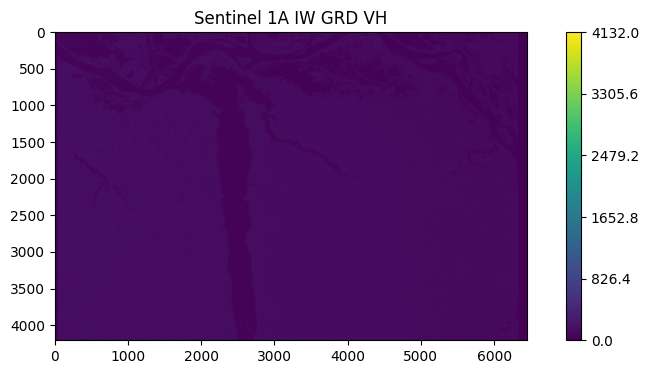

In [53]:
import rasterio
from rasterio.plot import show
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

path = "S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.zip/" \
       "S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.SAFE/" \
       "measurement/" \
       "s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff"

dataset = rasterio.open(f'/vsizip/{path}')

# resample data to not overload memory when showing
downscale_factor = 0.25
data = dataset.read(
    out_shape=(
        dataset.count,
        int(dataset.height * downscale_factor),
        int(dataset.width * downscale_factor)
    ),
    resampling=Resampling.bilinear
    )

fig, ax = plt.subplots(figsize=(10, 4))

ax = show(data, transform=dataset.transform, cmap='viridis',ax=ax)
im = ax.images[0]
cbar = fig.colorbar(im, ax=ax)
ticks = np.linspace(data.min(), data.max(), len(cbar.get_ticks()))
cbar.set_ticks(cbar.get_ticks())
cbar.ax.set_yticklabels([f"{t}" for t in ticks])
plt.title("Sentinel 1A IW GRD VH")
plt.show()

### **2.3 Categoria histograma**
 
Muito escuro? Uma dica é checar o histograma e encontrar os valores menos comuns de pixels e cortá-los da plotagem.

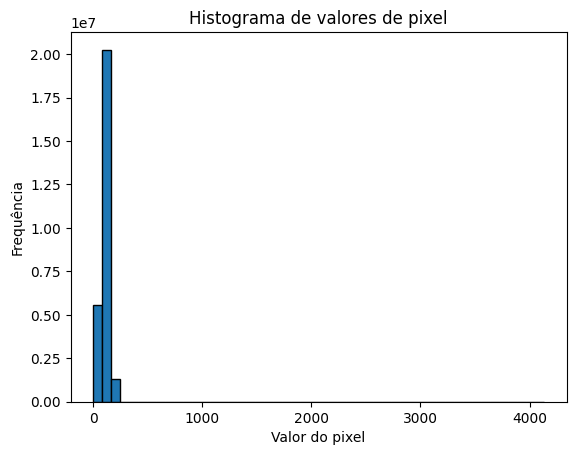

In [54]:
import numpy as np

frequencies, bin_edges = np.histogram(data, bins=50)
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(frequencies))]
bin_widths = [bin_edges[i+1] - bin_edges[i] for i in range(len(frequencies))]

# Plot as a histogram-like bar chart
plt.bar(bin_centers, frequencies, width=bin_widths, align='center', edgecolor='black')
plt.xlabel('Valor do pixel')
plt.ylabel('Frequência')
plt.title('Histograma de valores de pixel')
plt.show()

### **2.3 Categoria histograma**

Percentis 2% e 98%: 0.00, 180.00


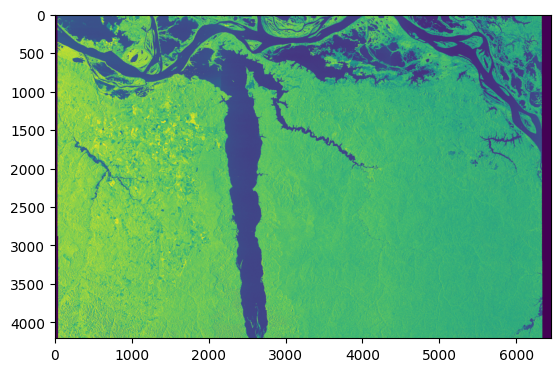

In [55]:
p2, p98 = np.nanpercentile(data, [2, 98])
print(f"Percentis 2% e 98%: {p2:.2f}, {p98:.2f}")
ax=show(data, cmap='viridis', percent_range=(2, 98))
ax.set_title("Sentinel 1A IW GRD VH"); plt.show()

### **2.4 Categoria SRC**

O SRC e a matriz de transformação do referencial matricial (col ,lin) para o SRC geográfico (lat, lon) estão **funcionando no QGIS mas parece quebrada pelo rasterio**

<img src="media/imgs/qgis-radar.png">

In [56]:
print("Transformação georreferenciada:\n", dataset.transform)
print("Sistema de referência de coordenadas (CRS):", dataset.crs)

Transformação georreferenciada:
 | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Sistema de referência de coordenadas (CRS): None


### **2.4 Categoria SRC**

**SRC definido através de pontos de controle**

In [ ]:
!"{qgis_bin_path}gdalinfo.exe" /vsizip/{path}

Driver: GTiff/GeoTIFF
Files: /vsizip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.zip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.SAFE/measurement/s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff
Size is 25803, 16828
GCP Projection = 
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.01745329251

### **2.4 Categoria SRC**

Temos uma lista de pontos de controle onde coordenadas geográficas ($\mathbf{x}$) e cada ponto da matriz ($\mathbf{p}$) estão relacionados, portanto é possível descobrir os parâmetros de uma transformação afim ($\mathbf{x} = R\mathbf{p}+\mathbf{t}$), denotado por $\mathbf{x}=(x_{geo},y_{geo})$ e $\mathbf{p} = (col,lin)$:

$$
\begin{bmatrix}
x_{geo}\\y_{geo}
\end{bmatrix} =
\begin{bmatrix}
a & b \\ d & e
\end{bmatrix}\begin{bmatrix}
col \\ lin
\end{bmatrix} + \begin{bmatrix}
c \\ f
\end{bmatrix}
$$

A forma homogênea aumentada é útil para obtenção da operação inversa:

$$
\begin{bmatrix}
x_{geo}\\y_{geo}\\1
\end{bmatrix} =
\underbrace{\begin{bmatrix}
a & b & c\\ d & e & f \\ 0 & 0 &1
\end{bmatrix}}_{T}\begin{bmatrix}
col \\ lin \\1
\end{bmatrix}
$$

E a operação inversa:

$$
\begin{bmatrix}
col \\ lin \\1
\end{bmatrix} =
T^{-1}
\begin{bmatrix}
x_{geo}\\y_{geo}\\1
\end{bmatrix}
$$

### **2.4 Categoria SRC**

**rasterio não está quebrada, temos que usar a função apropriada**: `rasterio.transform.from_gcps(gcps)`

In [58]:
import numpy as np
from IPython.display import display

gcps, gcp_crs = dataset.gcps
transform = rasterio.transform.from_gcps(gcps)

print(f"1º ponto de controle 1/{len(gcps)}:\n", gcps[0])
print("\nSistema de referência de coordenadas (CRS):", gcp_crs)

T = np.array([[transform.a, transform.b, transform.c],
               [transform.d, transform.e, transform.f],
               [0, 0, 1]])
print("T =\n",T)
print("T * [0.5, 0.5, 1] =\n", T @ np.array([[ 0.5], [0.5], [1]]))

1º ponto de controle 1/210:
 GroundControlPoint(row=0.0, col=0.0, x=-54.09272109842591, y=-2.25979451820512, z=4.000013970769942, id='1', info='')

Sistema de referência de coordenadas (CRS): EPSG:4326
T =
 [[-8.78766705e-05 -1.92048507e-05 -5.40925458e+01]
 [ 1.92356458e-05 -8.96903265e-05 -2.26126571e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
T * [0.5, 0.5, 1] =
 [[-54.09259935]
 [ -2.26130094]
 [  1.        ]]


### **2.4 Categoria SRC**

**Comparação da coordenada informada e a calculada**

In [59]:
def pixel_to_geo(T, px, py):
    x = T @ np.array([[px], [py], [1]])
    x = x.flatten() 
    return float(x[0]), float(x[1])

for gcp in gcps:
    px, py = gcp.col+0.5, gcp.row+0.5
    x_geo, y_geo = pixel_to_geo(T, px, py)
    print(f"GCP: pixel ({gcp.col}, {gcp.row})")
    print(f"  Geo coords:\t\t  ({gcp.x}, {gcp.y})")
    print(f"  Transformed Geo coords: ({x_geo}, {y_geo})")

GCP: pixel (0.0, 0.0)
  Geo coords:		  (-54.09272109842591, -2.25979451820512)
  Transformed Geo coords: (-54.09259935340049, -2.261300935164792)
GCP: pixel (1291.0, 0.0)
  Geo coords:		  (-54.20643347840277, -2.2351056355540617)
  Transformed Geo coords: (-54.20604813506719, -2.2364677163857323)
GCP: pixel (2582.0, 0.0)
  Geo coords:		  (-54.3199308546809, -2.2104543215919605)
  Transformed Geo coords: (-54.319496916733904, -2.2116344976066724)
GCP: pixel (3873.0, 0.0)
  Geo coords:		  (-54.43324748544489, -2.1858332835338987)
  Transformed Geo coords: (-54.43294569840061, -2.186801278827613)
GCP: pixel (5164.0, 0.0)
  Geo coords:		  (-54.546529702778514, -2.1612107865970156)
  Transformed Geo coords: (-54.54639448006731, -2.161968060048553)
GCP: pixel (6455.0, 0.0)
  Geo coords:		  (-54.65998082738782, -2.1365424343461483)
  Transformed Geo coords: (-54.659843261734025, -2.1371348412694933)
GCP: pixel (7746.0, 0.0)
  Geo coords:		  (-54.77358523401175, -2.111831752150094)
  Transform

### **2.4 Categoria SRC**

**Alterar o modo de georrefereciamento com** `gdalwarp`

A utilidade [gdalwarp](https://manpages.opensuse.org/Leap-15.6/gdal/gdalwarp.1.en.html) realiza trasnformações de imagens, reprojeção e e distorções. O programa pode reprojetar para qualquer projeção suportada, e também pode aplicar GCPs armazenados com a imagem se a imagem for "bruto" com informações de controle.

In [ ]:
# !"{qgis_bin_path}gdalinfo.exe" /vsizip/{path} -mm
!"{qgis_bin_path}gdalwarp.exe" -ovr 0 /vsizip/{path} vh.tif
!"{qgis_bin_path}gdalwarp.exe" -ovr 1 /vsizip/{path} vh1.tif
!"{qgis_bin_path}gdalwarp.exe" -ovr 2 /vsizip/{path} vh2.tif
# !"{qgis_bin_path}gdalinfo.exe" vh.tif

Using internal nodata values (e.g. 0) for image /vsizip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.zip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.SAFE/measurement/s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff.
Processing s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Using internal nodata values (e.g. 0) for image /vsizip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.zip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322_062411_07D166_AC8A_COG.SAFE/measurement/s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff.
Processing s1a-iw-grd-vh-20251221t092257-20251221t092322-062411-07d166-002-cog.tiff [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Using internal nodata values (e.g. 0) for image /vsizip/S1A_IW_GRDH_1SDV_20251221T092257_20251221T092322

### **2.4 Categoria SRC**

**Exibição georreferenciada**

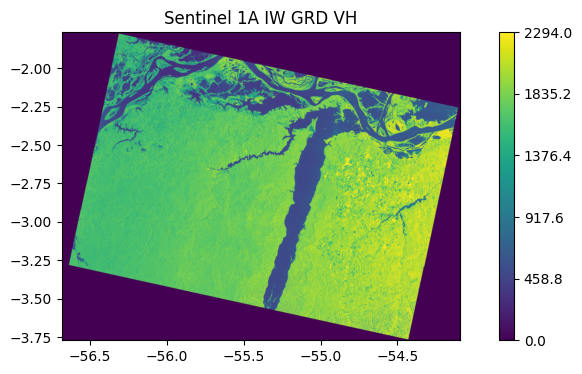

In [61]:
import rasterio
from rasterio.plot import show

dataset = rasterio.open(f'vh2.tif')
data = dataset.read()

fig, ax = plt.subplots(figsize=(10, 4))

show(data, transform=dataset.transform, percent_range=(2, 98), cmap='viridis', ax=ax)
im = ax.images[0]
cbar = fig.colorbar(im, ax=ax)
ticks = np.linspace(data.min(), data.max(), len(cbar.get_ticks()))
cbar.set_ticks(cbar.get_ticks())
cbar.ax.set_yticklabels([f"{t}" for t in ticks])
plt.title("Sentinel 1A IW GRD VH"); plt.show()

### **2.5 Categoria NoData e tipo de valor**

**Dataset de referência**: [CopDEM COG (30 m)](https://browser.stac.dataspace.copernicus.eu/collections/cop-dem-glo-30-dged-cog) que representam a superfície da Terra, incluindo edifícios, infraestrutura e vegetação, com resolução de 30 metros. Em uma tentativa de redução de seu tamanho em disco, ficou da seguinte maneira:


In [62]:
from pystac_client import Client

catalogo = Client.open("https://stac.dataspace.copernicus.eu/v1/")
colecao = catalogo.get_collection("cop-dem-glo-30-dged-cog")
search = catalogo.search(
  collections=["cop-dem-glo-30-dged-cog"], # coleções DEM global do Copernicus
  bbox = [-48.9, -0.8, -48.9, -0.8]  # [top-left, bottom-right] of aoi polygon
)
items = list(search.items())
url = items[0].assets["data"].href
print("Quantidade de MDEs encontrados:", len(items), )
print("ID do MDE encontrados:", items[0].id)
tile_id = items[0].id
item = colecao.get_item(tile_id)
print("URL:", url)

Quantidade de MDEs encontrados: 1
ID do MDE encontrados: Copernicus_DSM_COG_10_S01_00_W049_00_DEM
URL: s3://eodata/auxdata/CopDEM_COG/copernicus-dem-30m/Copernicus_DSM_COG_10_S01_00_W049_00_DEM/Copernicus_DSM_COG_10_S01_00_W049_00_DEM.tif


In [ ]:
# Documentação completa:
# https://documentation.dataspace.copernicus.eu/APIs/S3.html?rsource=https%3A%2F%2Flinks.esri.com%2FEO_data_via_S3_doc
# Gere credenciais de acesso ao bucket S3 do Copernicus para baixar o MDE em:
# https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials
# PS > aws configure
# AWS Access Key ID [None]: YOUR_ACCESS_KEY_ID_HERE
# AWS Secret Access Key [None]: YOUR_SECRET_ACCESS_KEY_HERE
cmd = fr".venv\Scripts\aws s3 cp {url} ./mde.tif --endpoint-url https://eodata.dataspace.copernicus.eu/ "
!{cmd}

Completed 256.0 KiB/23.8 MiB (141.5 KiB/s) with 1 file(s) remaining
Completed 512.0 KiB/23.8 MiB (282.6 KiB/s) with 1 file(s) remaining
Completed 768.0 KiB/23.8 MiB (420.0 KiB/s) with 1 file(s) remaining
Completed 1.0 MiB/23.8 MiB (502.8 KiB/s) with 1 file(s) remaining  
Completed 1.2 MiB/23.8 MiB (627.8 KiB/s) with 1 file(s) remaining  
Completed 1.5 MiB/23.8 MiB (746.3 KiB/s) with 1 file(s) remaining  
Completed 1.8 MiB/23.8 MiB (812.9 KiB/s) with 1 file(s) remaining  
Completed 2.0 MiB/23.8 MiB (927.7 KiB/s) with 1 file(s) remaining  
Completed 2.2 MiB/23.8 MiB (1.0 MiB/s) with 1 file(s) remaining    
Completed 2.5 MiB/23.8 MiB (1.1 MiB/s) with 1 file(s) remaining    
Completed 2.8 MiB/23.8 MiB (1.2 MiB/s) with 1 file(s) remaining    
Completed 3.0 MiB/23.8 MiB (1.3 MiB/s) with 1 file(s) remaining    
Completed 3.2 MiB/23.8 MiB (1.3 MiB/s) with 1 file(s) remaining    
Completed 3.5 MiB/23.8 MiB (1.5 MiB/s) with 1 file(s) remaining    
Completed 3.8 MiB/23.8 MiB (1.5 MiB/s) with 1 fi

Associa��o de arquivo n�o encontrada para a extens�o .py


In [ ]:
# quebrar o mde.tif
!"{qgis_bin_path}gdalwarp.exe" -ot Byte -dstnodata 0 mde.tif mde_broke.tif

ERROR 1: Output dataset mde_broke.tif exists,
but some command line options were provided indicating a new dataset
should be created.  Please delete existing dataset and run again.



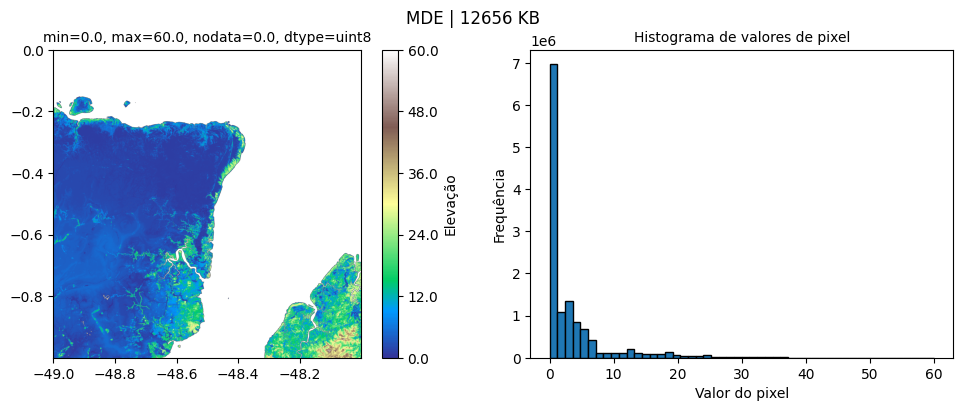

In [65]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

mde = rasterio.open("./mde_broke.tif")
data = mde.read()
fig, ax = plt.subplots(1,2,figsize=(12, 4))
show(mde,ax=ax[0], cmap="terrain")
im = ax[0].images[0]
cbar = fig.colorbar(im, ax=ax[0])
ticks = np.linspace(data.min(), data.max(), len(cbar.get_ticks()))
cbar.set_ticks(cbar.get_ticks())
cbar.ax.set_yticklabels([f"{t}" for t in ticks])
cbar.set_label("Elevação")
ax[0].set_title(f"min={data.min():.1f}, max={data.max():.1f}, nodata={mde.nodata}, dtype={data.dtype}", size=10)

frequencies, bin_edges = np.histogram(data, bins=50)
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(frequencies))]
bin_widths = [bin_edges[i+1] - bin_edges[i] for i in range(len(frequencies))]

# Plot as a histogram-like bar chart
ax[1].bar(bin_centers, frequencies, width=bin_widths, align='center', edgecolor='black')
ax[1].set_xlabel('Valor do pixel')
ax[1].set_ylabel('Frequência')
ax[1].set_title('Histograma de valores de pixel', size=10)

plt.suptitle(f"MDE | {int(data.nbytes/1024)} KB")
plt.show()

### **2.5 Categoria NoData e tipo de valor**

O que tinha de errado? Como seria o certo?

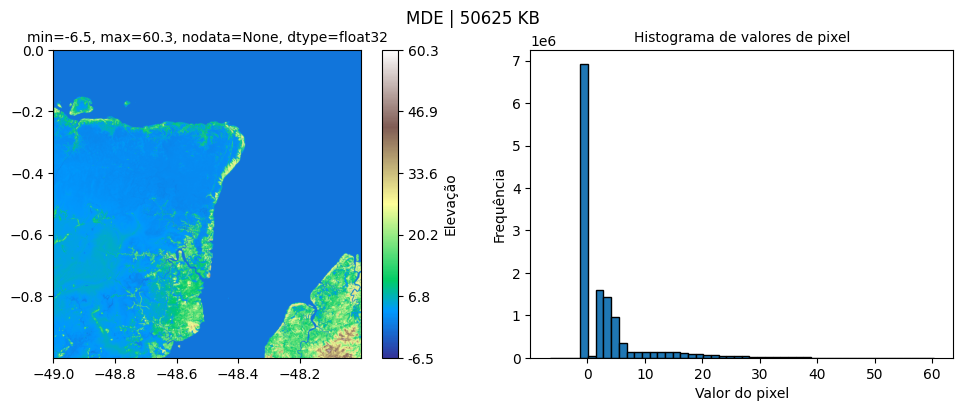

In [66]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

mde = rasterio.open("./mde.tif")
data = mde.read()
fig, ax = plt.subplots(1,2,figsize=(12, 4))
show(mde,ax=ax[0], cmap="terrain")
im = ax[0].images[0]
cbar = fig.colorbar(im, ax=ax[0])
ticks = np.linspace(data.min(), data.max(), len(cbar.get_ticks()))
cbar.set_ticks(cbar.get_ticks())
cbar.ax.set_yticklabels([f"{t:.1f}" for t in ticks])
cbar.set_label("Elevação")
ax[0].set_title(f"min={data.min():.1f}, max={data.max():.1f}, nodata={mde.nodata}, dtype={data.dtype}", size=10)

frequencies, bin_edges = np.histogram(data, bins=50)
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(frequencies))]
bin_widths = [bin_edges[i+1] - bin_edges[i] for i in range(len(frequencies))]

# Plot as a histogram-like bar chart
ax[1].bar(bin_centers, frequencies, width=bin_widths, align='center', edgecolor='black')
ax[1].set_xlabel('Valor do pixel')
ax[1].set_ylabel('Frequência')
ax[1].set_title('Histograma de valores de pixel', size=10)

plt.suptitle(f"MDE | {int(data.nbytes/1024)} KB")
plt.show()

### **2.6 Categoria resolução**

Quais bandas escolher para realizar a aritimética de bandas de imagens Sentinel-2 para compor o índice de vegetação REDEDGE por diferença normalizada (NDRE):

NDRE = (NIR - REDEDGE) /(NIR + REDEDGE)

| Nome | Descrição | GSD | Nome Comum |
|---|---|---:|---|
| B01 | Coastal aerosol (band 1) | 60 m | coastal |
| B02 | Blue (band 2) | 10 m | blue |
| B03 | Green (band 3) | 10 m | green |
| B04 | Red (band 4) | 10 m | red |
| B05 | Red edge 1 (band 5) | 20 m | rededge071 |
| B06 | Red edge 2 (band 6) | 20 m | rededge075 |
| B07 | Red edge 3 (band 7) | 20 m | rededge078 |
| B08 | NIR 1 (band 8) | 10 m | nir |
| B8A | NIR 2 (band 8A) | 20 m | nir08 |
| B09 | NIR 3 (band 9) | 60 m | nir09 |
| B11 | SWIR 1 (band 11) | 20 m | swir16 |
| B12 | SWIR 2 (band 12) | 20 m | swir22 |


<img src="media/imgs/aritmetica.png">

### **2.6.1 Técnicas de reamostragem**

| Método comuns | Como funciona | Indicado para | Limitações | 
|---|---|---|---|
| Vizinho mais próximo (*nearest neighbour*) | Copia o valor do pixel mais próximo da nova posição. | Dados categóricos, máscaras, rasters classificados.| Pode gerar aparência serrilhada e deslocamentos visuais. | 
| Bilinear | Calcula média ponderada dos quatro pixels vizinhos. | Dados contínuos, como reflectância e MDE. | Altera os valores originais; não deve ser usado em classes. | 
| Cúbica (*cubic convolution*) | Interpola usando uma vizinhança maior, geralmente 16 pixels. | Dados contínuos quando se deseja maior suavização. | Pode criar valores fora do intervalo original e aumentar artefatos. | 
| Média (*average*) | Agrega os pixels de entrada que contribuem para cada pixel de saída. | Redução de resolução de dados contínuos. | Não é adequado para ampliar resolução nem para classes nominais. | 
| Moda (*mode*) | Usa a classe mais frequente dentro da área do novo pixel. | Redução de resolução de dados categóricos. | Pode eliminar classes raras ou estreitas. |


### **2.6.2 Reamostragem bilinear**

<img src="media/imgs/bilinear.png">

### **2.6.3 Exemplo: Reamostragem com [gdalwarp](https://manpages.opensuse.org/Leap-15.6/gdal/gdalwarp.1.en.html#r)** 

```bash
gdalwarp -tr 10 10 -r bilinear banda_20m.tif banda_10m.tif
```

O parâmetro `-tr 10 10` define o tamanho do pixel de saída e `-r bilinear` define o método de reamostragem.

## Lista de exercícios

**Exercício 1.** Faça o download dos [bairros da cidade de manaus](https://github.com/HumbertoDiego/mapa-criminalidade-bairros-manaus/blob/main/bairros_manaus_4326.geojson) e realize a validação geométrica através das ferramentas nativas do QGIS (`qgis_process native:checkgeometry`), dando preferência pela interface CLI.


**Exercício 2.** Faça o download das bandas NIR e REDGEDGE de uma imagem qualquer Sentinel-2. Confecione uma imagem de **GSD 10m** com o cálculo do índice de vegetação RedEdge normalizado (NDRE = (NIR - REDEDGE) /(NIR + REDEDGE)). 


## 3. Aplicar métodos de detecção de outliers na limpeza de dados

Além de **identificar problemas no diagnóstico**, corrigindo-os ou removendo-os, durante a limpeza se detecta os *outliers*: valores que se afastam significativamente dos demais. 

> Nem todo *outlier* é erro ou é inválido — pode ser um evento extremo real. Em determinadas [situações](https://arxiv.org/abs/2606.03673), é justamente o que precisa ser encontrado e estudado. A decisão de remover ou manter deve ser embasada no contexto.

### **3.1 Detecção de outliers Método IQR (Intervalo Interquartil)**

<img src="media/imgs/iqr.png">

### **3.2 Exemplo: Aplicação do método IQR**

**1º Passo:** Voltaremos a usar os dados pluviométricos sintéticos. Já removido irrelevantes, inválidos e duplicatas.

In [67]:
df_clean = df.loc[~df['ativo']==False]
df_clean = df_clean[~( (df_clean['latitude'].abs()  > 90) | 
                       (df_clean['longitude'].abs() > 180) 
                       )]
df_clean = df_clean[~df_clean[['precip_jan_mm','precip_fev_mm']].ge(9000).any(axis=1)]
df_clean = df_clean[~df_clean.duplicated(subset=['latitude','longitude'], keep="first")]
df_clean

,id,nome,municipio,latitude,longitude,precip_jan_mm,precip_fev_mm,ativo
0,0,Posto A,Niterói,-22.88,-43.10,120.5,110.2,True
1,1,Posto B,Rio de Janeiro,-22.90,-43.17,NaN,142.1,True
2,2,Posto C,Petrópolis,-22.51,-43.18,98.3,91.7,True
3,3,Posto D,Angra dos Reis,-23.01,-44.32,135.0,88.0,True
5,5,Posto F,Volta Redonda,-22.52,-44.08,88.7,80.1,True
8,8,Posto I,Resende,-22.47,-44.45,61.4,58.2,True
9,9,Posto J,Macaé,-22.38,-41.79,110.2,105.3,True
10,10,Posto K,Cabo Frio,-22.88,-42.02,95.8,91.1,True


**2º Passo:**  Uso do boxplot

- Resumir a distribuição de uma variável numérica
- Mostrar a mediana (Q2), os quartis (Q1 e Q3) e o intervalo interquartil (IQR)
- Comparar distribuições e entender assimetrias
- Identificar valores extremos rapidamente

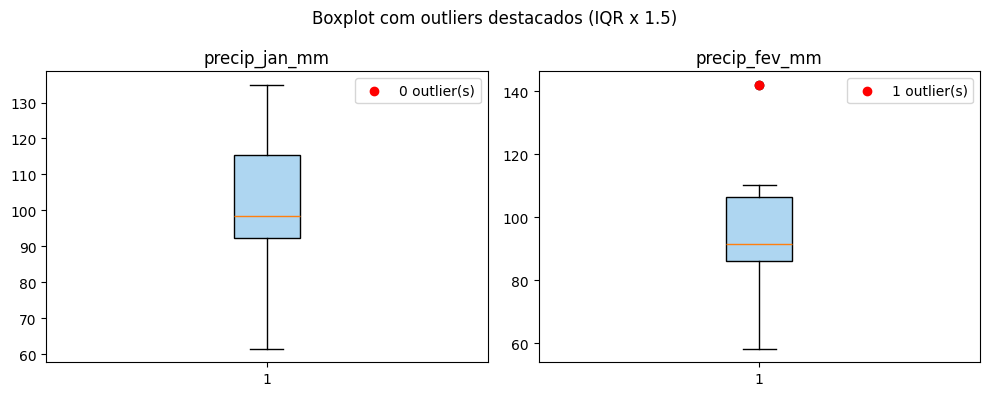

In [68]:
def detectar_outliers_iqr(serie):
    """Retorna máscara booleana com True onde há outlier pelo critério IQR."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ["precip_jan_mm", "precip_fev_mm"]):
    serie = df_clean[col].dropna()
    outliers = detectar_outliers_iqr(serie)
    ax.boxplot(serie, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'))
    ax.scatter(
        [1] * outliers.sum(),
        serie[outliers],
        color='red', zorder=5, label=f"{outliers.sum()} outlier(s)"
    )
    ax.set_title(col)
    ax.legend()

plt.suptitle("Boxplot com outliers destacados (IQR x 1.5)", fontsize=12)
plt.tight_layout()
plt.show()

### **3.3 Detecção de outliers Método Z-score**

<img src="media/imgs/zsocre.png">


### **3.4 Exemplo: A aplicação do Método Z-score**

**1º Passo** Será simulado um conjunto observações de uma medida de distância. A maior parte das medições ficará próxima de um valor verdadeiro, seguindo uma distribuição normal. Em seguida, serão inseridos alguns **erros grosseiros** para verificar se o método Z-score consegue identificá-los como possíveis *outliers*.

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reprodutibilidade
np.random.seed(42)

# Dataset: 1000 medidas de distancia com erro aleatorio normal
n_obs = 1000
distancia_real_m = 50.0
erro_instrumental_m = 0.90

medidas = np.random.normal(
    loc=distancia_real_m,
    scale=erro_instrumental_m,
    size=n_obs
)

# Insercao de erros grosseiros em algumas observacoes
indices_erros_grosseiros = [8, 27, 63, 91]
medidas[indices_erros_grosseiros] = [46.8, 53.5, 45.9, 54.2]

df_dist = pd.DataFrame({
    "observacao": np.arange(1, n_obs + 1),
    "distancia_m": medidas,
})

df_dist["erro_grosseiro_inserido"] = False
df_dist.loc[indices_erros_grosseiros, "erro_grosseiro_inserido"] = True

df_dist

,observacao,distancia_m,erro_grosseiro_inserido
0,1,50.447043,False
1,2,49.875562,False
2,3,50.582920,False
3,4,51.370727,False
4,5,49.789262,False
...,...,...,...
995,996,49.747010,False
996,997,51.617918,False
997,998,50.576759,False
998,999,49.485939,False


**2º Passo:** Checagem se a distribuição é aproximadamente normal

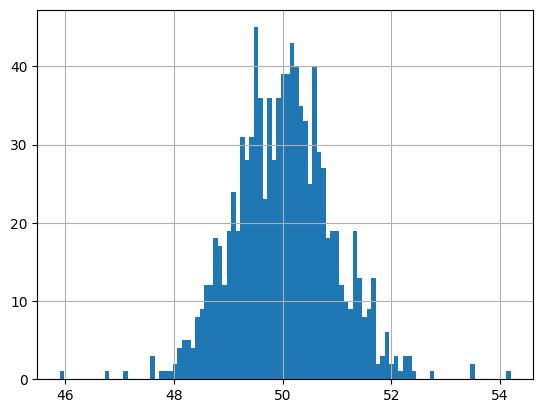

In [70]:
df_dist["distancia_m"].hist(bins=100,); plt.show()

**3º Passo:** Aplicação e detecção

In [71]:
# Metodo Z-score
media = df_dist["distancia_m"].mean()
desvio_padrao = df_dist["distancia_m"].std(ddof=0)

df_dist["z_score"] = (df_dist["distancia_m"] - media) / desvio_padrao

limiar = 3
df_dist["outlier_zscore"] = df_dist["z_score"].abs() > limiar

outliers_zscore = df_dist[df_dist["outlier_zscore"]]

print(f"Média: {media:.3f} m")
print(f"Desvio-padrão: {desvio_padrao:.3f} m")
print(f"Limiar Z-score: |z| > {limiar}")
print(f"Outliers encontrados: {len(outliers_zscore)}")

Média: 50.018 m
Desvio-padrão: 0.911 m
Limiar Z-score: |z| > 3
Outliers encontrados: 7


In [72]:
display(outliers_zscore)

,observacao,distancia_m,erro_grosseiro_inserido,z_score,outlier_zscore
8,9,46.800000,True,-3.531020,True
27,28,53.500000,True,3.820499,True
63,64,45.900000,True,-4.518538,True
91,92,54.200000,True,4.588568,True
209,210,53.467458,False,3.784793,True
262,263,47.082859,False,-3.220655,True
478,479,52.770993,False,3.020602,True


**4º Passo:** Plotagem

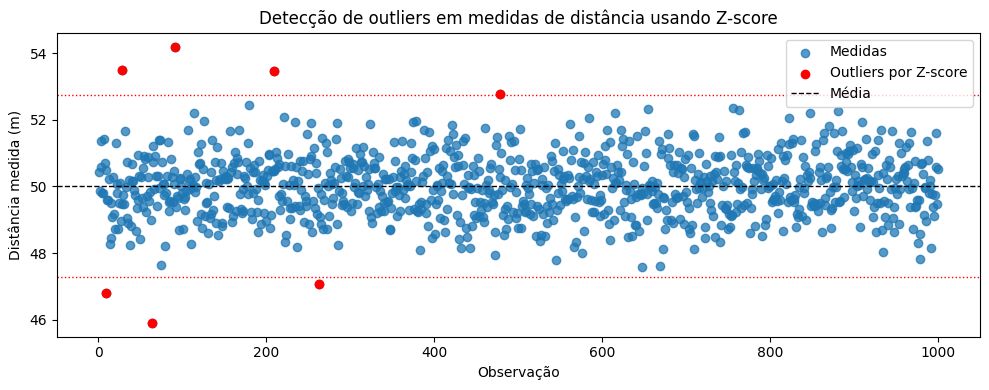

In [73]:
# plot
plt.figure(figsize=(10, 4))
plt.scatter(
    df_dist["observacao"],
    df_dist["distancia_m"],
    label="Medidas",
    alpha=0.75
)
plt.scatter(
    outliers_zscore["observacao"],
    outliers_zscore["distancia_m"],
    color="red",
    label="Outliers por Z-score",
    zorder=5
)
plt.axhline(media, color="black", linestyle="--", linewidth=1, label="Média")
plt.axhline(media + limiar * desvio_padrao, color="red", linestyle=":", linewidth=1)
plt.axhline(media - limiar * desvio_padrao, color="red", linestyle=":", linewidth=1)
plt.xlabel("Observação")
plt.ylabel("Distância medida (m)")
plt.title("Detecção de outliers em medidas de distância usando Z-score")
plt.legend()
plt.tight_layout()
plt.show()

**5º Passo:** histograma violino com boxplot interno

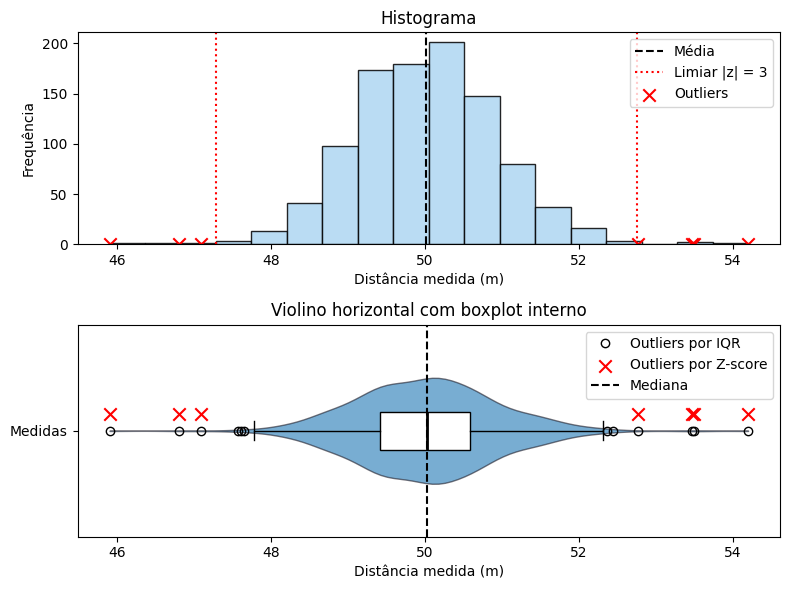

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Histograma da distribuição das medidas
axes[0].hist(
    df_dist["distancia_m"],
    bins=18,
    color="#AED6F1",
    edgecolor="black",
    alpha=0.85
)
axes[0].axvline(media, color="black", linestyle="--", linewidth=1.5, label="Média")
axes[0].axvline(media + limiar * desvio_padrao, color="red", linestyle=":", linewidth=1.5, label="Limiar |z| = 3")
axes[0].axvline(media - limiar * desvio_padrao, color="red", linestyle=":", linewidth=1.5)
axes[0].scatter(
    outliers_zscore["distancia_m"],
    np.zeros(len(outliers_zscore)),
    color="red",
    marker="x",
    s=80,
    label="Outliers"
)
axes[0].set_title("Histograma")
axes[0].set_xlabel("Distância medida (m)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Gráfico de violino horizontal com boxplot interno
violino = axes[1].violinplot(
    df_dist["distancia_m"],
    vert=False,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for corpo in violino["bodies"]:
    # corpo.set_facecolor("#3B96E0")
    corpo.set_edgecolor("#1D1B27")
    corpo.set_alpha(0.6)

bp = axes[1].boxplot(
        df_dist["distancia_m"],
        vert=False,
        widths=0.18,
        patch_artist=True,
        showfliers=True,
        boxprops=dict(facecolor="white", edgecolor="black"),
        medianprops=dict(color="black", linewidth=2),
        # flierprops=dict(marker="o", markerfacecolor="white", markeredgecolor="k", markersize=7)
    )
bp['fliers'][0].set_label('Outliers por IQR')

axes[1].scatter(
    outliers_zscore["distancia_m"],
    np.ones(len(outliers_zscore)) * 1.08,
    color="red",
    marker="x",
    s=80,
    label="Outliers por Z-score"
)

axes[1].axvline(df_dist["distancia_m"].median(), color="black", 
                linestyle="--", linewidth=1.5, label="Mediana")

axes[1].set_title("Violino horizontal com boxplot interno")
axes[1].set_xlabel("Distância medida (m)")
axes[1].set_yticks([1])
axes[1].set_yticklabels(["Medidas"])
axes[1].legend()

plt.tight_layout()
plt.show()

### **3.5 Detecção de outliers Método RANSAC (RANdom SAmple Consensus)**

<img src="media/imgs/ransac.png">

### **3.6 Exemplo: Aplicação do RANSAC via** `sklearn.linear_model.RANSACRegressor`

**1º Passo**: Dados com outliers

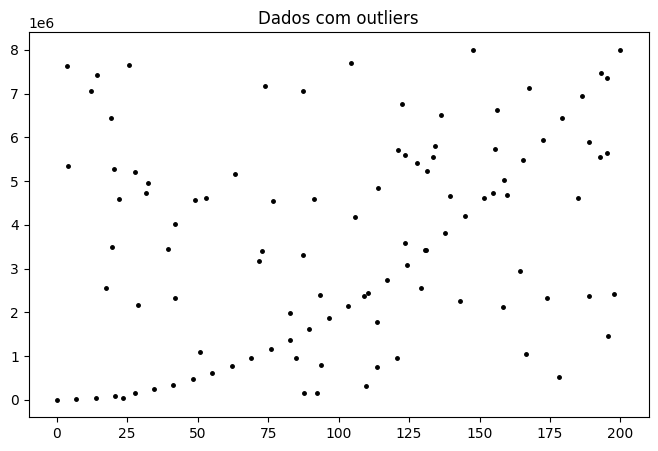

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Curved line: y as a function of x (parabola)
x_curve = np.linspace(0, 200, 30)
y_curve = 200 + 200*(x_curve**2)

# noise
# Reproducible randomness
np.random.seed(0)
# Canvas size
w, h = 200, y_curve.max()

# Sparse random points
n_points = 75
x_pts = np.random.uniform(0, w, n_points)
y_pts = np.random.uniform(0, h, n_points)

# misturar a curva e o ruído
x = np.hstack((x_pts, x_curve))
y = np.hstack((y_pts, y_curve))
pts = np.column_stack((x, y))
pts = pts[pts[:, 0].argsort()]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(pts[:,0], pts[:,1], s=25, c="black", marker=".")

plt.title("Dados com outliers")
plt.show()


**2º Passo:** Configuração de parâmetros e estimativa de modelo

In [76]:
# Parâmetros importantes
min_samples = 3
residual_threshold = 0.01 * (pts[:,1].max()-pts[:,1].min()) # ajuste conforme a escala do seu y

# modelo
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.pipeline import make_pipeline

# Modelo previsto: y = f(x²,x) = ax² + bx + c 
# Mas o vetor de características é apenas f(x) representado por X (105,1), 
# temos que adicionar um coluna extra com os quadrados X (105,2) --> f(x²,x)
model = make_pipeline(
  PolynomialFeatures(degree=2, include_bias=False), # adiciona coluna x²
  RANSACRegressor(
    estimator=LinearRegression(), # Como a coluna x² foi adicionada no passo 
                                  # anterior, essa regressão linear vai 
                                  # funcionar como uma regressão polinomial
    residual_threshold=residual_threshold,
    min_samples=min_samples,
    random_state=0
  ),
)

**3º Passo:** Iteração e consenso

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# x precisa ser 2D para o sklearn
X = pts[:, 0].reshape(-1, 1)
Y = pts[:, 1].reshape(-1, 1)

model.fit(X, Y)

# Máscara dos pontos bons e ruins
ransac = model.named_steps["ransacregressor"]
inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask

pts_inliers = pts[inlier_mask]
pts_outliers = pts[outlier_mask]

print("Inliers:", pts_inliers.shape)
print("Outliers:", pts_outliers.shape)

Inliers: (34, 2)
Outliers: (71, 2)


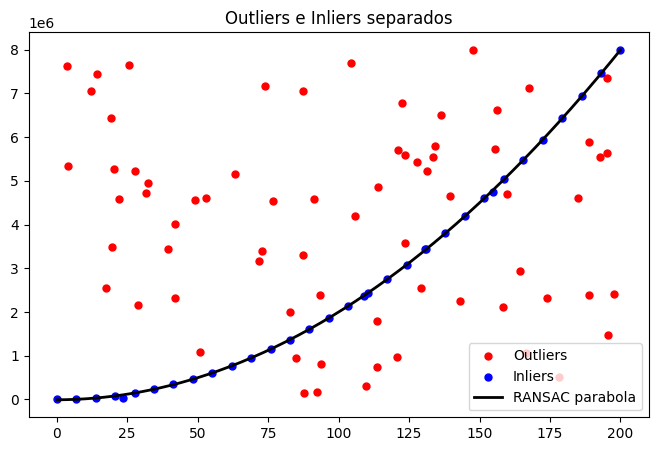

In [78]:
x_fit = np.linspace(pts[:, 0].min(), pts[:, 0].max(), 300).reshape(-1, 1)
y_fit = model.predict(x_fit)

plt.figure(figsize=(8, 5))
plt.scatter(pts_outliers[:, 0], pts_outliers[:, 1], c="red", s=25, label="Outliers")
plt.scatter(pts_inliers[:, 0], pts_inliers[:, 1], c="blue", s=25, label="Inliers")
plt.plot(x_fit, y_fit, c="black", linewidth=2, label="RANSAC parabola")
plt.legend()
plt.title("Outliers e Inliers separados")
plt.show()

## 4. Aplicar métodos de completamento de dados

**Completamento** (ou *imputation*) é o processo de preencher valores ausentes com estimativas razoáveis. Há uma hierarquia de estratégias — da mais simples à mais sofisticada.

### **4.1 Estratégias de completamento**

| Estratégia | Descrição | Quando usar |
|-----------|-----------|-------------|
| **Média / Mediana** | Substitui pelo valor central da coluna | Distribuições simétricas / com outliers |
| **Moda** | Substitui pelo valor mais frequente | Variáveis categóricas |
| **Interpolação temporal** | Usa vizinhos no tempo | Séries temporais |
| **Interpolação espacial** | Usa vizinhos no espaço | Dados geoespaciais |
| **Modelo preditivo** | Treina um modelo para prever | Dados complexos com padrão |


### **4.2 Completamento por média**

É uma estratégia <b style="color:#2ECC40">simples e rápida</b>, adequada quando a <b  style="color:#ffff00">distribuição é aproximadamente simétrica</b> e quando <b  style="color:#ffff00">não há uma estrutura temporal ou espacial</b> importante a ser preservada. 

A principal limitação é que ela <b style="color:#CC2E40"> reduz artificialmente a variabilidade</b> dos dados e pode ser <b style="color:#CC2E40">distorcida por outliers</b>.

In [79]:
df_media = df.copy()

media_precip_jan = df_media['precip_jan_mm'].mean()
df_media['precip_jan_mm_media'] = df_media['precip_jan_mm'].fillna(media_precip_jan)
show_cols = ['nome', 'municipio', 'precip_jan_mm', 'precip_jan_mm_media']
df_media.loc[df['precip_jan_mm'].isna(), show_cols]

,nome,municipio,precip_jan_mm,precip_jan_mm_media
1,Posto B,Rio de Janeiro,NaN,112.963636


### **4.3 Completamento por moda**

Também <b style="color:#2ECC40">simples e rápida</b>. Especialmente útil para <b style="color:#ffff00">variáveis categóricas</b>, como classe de uso do solo, tipo de litologia, município, status de operação ou qualquer atributo discreto.

Da mesma maneira que o completamento pela média, <b style="color:#CC2E40"> reduz artificialmente a diversidade</b>, além de <b style="color:#CC2E40">ignorar correlações mais importantes que a frequência</b> que poderiam estar presentes nos dados.


In [80]:
df_moda = df.copy()

# Valores ausentes artificiais para demonstrar o método em uma coluna categórica.
indices_sem_municipio = [3, 7]
df_moda.loc[indices_sem_municipio, 'municipio'] = np.nan

moda_municipio = df_moda['municipio'].mode(dropna=True).iloc[0]
df_moda['municipio_moda'] = df_moda['municipio'].fillna(moda_municipio)
show_cols = ['nome', 'municipio', 'municipio_moda']

df_moda.loc[indices_sem_municipio, show_cols]

,nome,municipio,municipio_moda
3,Posto D,NaN,Niterói
7,Posto H,NaN,Niterói


### **4.4 Completamento por interpolação temporal**

A interpolação mais simples é a **interpolação linear** que estima valores ausentes usando a sequência dos dados. Em séries temporais, a ideia é usar os valores vizinhos antes e depois $(y_0, y_1)$ da lacuna $(\hat{y})$ para reconstruir uma tendência local:

$$\hat{y}(t)=y_0 + \frac{y_1-y_0}{t_1-t_0}(t-t_0)$$

Esse método é <b style="color:#2ECC40">mais informativo que a média quando a ordem das observações importa</b>. A interpolação linear <b style="color:#ffff00">assume variação gradual entre os pontos observados</b>; se houver saltos bruscos, o resultado deve ser interpretado com cuidado.

In [81]:
import numpy as np

serie_chuva = pd.Series(
    [120.5, np.nan, 98.3, 110.0, np.nan, 88.7],
    index=pd.date_range('2026-01-01', periods=6, freq='MS'),
    name='precipitacao_mm'
)

df_interpolacao = serie_chuva.to_frame()
df_interpolacao['precipitacao_interpolada'] = df_interpolacao['precipitacao_mm'].interpolate(method='time')

df_interpolacao

,precipitacao_mm,precipitacao_interpolada
2026-01-01,120.5,120.500000
2026-02-01,NaN,108.835593
2026-03-01,98.3,98.300000
2026-04-01,110.0,110.000000
2026-05-01,NaN,99.524590
2026-06-01,88.7,88.700000


### **4.5 Completamento por interpolação espacial**

Em dados geoespaciais, o princípio de **Tobler** — *"tudo está relacionado com tudo, mas coisas próximas mais do que coisas distantes"* — sugere que usar vizinhos espaciais é mais adequado que uma estatística global.

O método mais simples é o **Inverso da Distância Ponderada (IDW)**:

$$\hat{z}(p) = \frac{\sum_{i=1}^{n} \frac{z_i}{d_i^\beta}}{\sum_{i=1}^{n} \frac{1}{d_i^\beta}}$$

onde $d_i$ é a distância ao ponto $i$, e $\beta$ é o expoente de ponderação (tipicamente 2).

### **4.6 Exemplo: Aplicação da iterpolação IDW**

**1º Passo** Será usado o dataset de postos pluviométricos já limpo, onde temos um ponto sem valores de precipitação, a qual queremos estimar e completar.

In [82]:
import geopandas as gpd
gdf = gpd.GeoDataFrame(df_clean, geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude), crs="EPSG:4326")
del gdf['latitude']; del gdf['longitude']; del gdf['precip_fev_mm'];del gdf['ativo']
gdf

,id,nome,municipio,precip_jan_mm,geometry
0,0,Posto A,Niterói,120.5,POINT (-43.1 -22.88)
1,1,Posto B,Rio de Janeiro,NaN,POINT (-43.17 -22.9)
2,2,Posto C,Petrópolis,98.3,POINT (-43.18 -22.51)
3,3,Posto D,Angra dos Reis,135.0,POINT (-44.32 -23.01)
5,5,Posto F,Volta Redonda,88.7,POINT (-44.08 -22.52)
8,8,Posto I,Resende,61.4,POINT (-44.45 -22.47)
9,9,Posto J,Macaé,110.2,POINT (-41.79 -22.38)
10,10,Posto K,Cabo Frio,95.8,POINT (-42.02 -22.88)


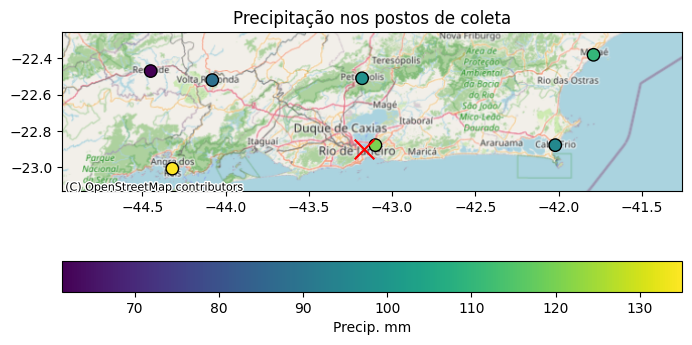

In [83]:
import contextily as cx

# Plot the GeoDataFrame with an OSM background
ax2 = gdf.plot(figsize=(8, 6), column='precip_jan_mm',
               edgecolor="black", markersize=80, legend=True,
               legend_kwds={"label": "Precip. mm", "orientation": "horizontal"})

ax2.set_title("Precipitação nos postos de coleta")
ax2.margins(0.2)

gdf[gdf['precip_jan_mm'].isnull()].plot(ax=ax2, marker='x', 
                                        markersize=200, color='red')

cx.add_basemap(ax2, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)


**2º Passo** Cálculo das distâncias aos vizinhos mais próximos

In [84]:
gdf_m = gdf.to_crs("EPSG:31983")  # SIRGAS 2000 / UTM 23S
id_nans = gdf[gdf['precip_jan_mm'].isnull()]['id'].values

id_nan = id_nans[0] # 1, <- subs laço for caso de vários

ponto_ref = gdf_m.loc[gdf_m["id"] == id_nan, "geometry"].iloc[0]
gdf_m[f"dist_id_{id_nan}_m"] = gdf_m.geometry.distance(ponto_ref)
del gdf_m['geometry']; del gdf_m['nome']
gdf_m


,id,municipio,precip_jan_mm,dist_id_1_m
0,0,Niterói,120.5,7516.517211
1,1,Rio de Janeiro,NaN,0.000000
2,2,Petrópolis,98.3,43202.258984
3,3,Angra dos Reis,135.0,118545.612684
5,5,Volta Redonda,88.7,102512.247195
8,8,Resende,61.4,139857.074578
9,9,Macaé,110.2,153163.784644
10,10,Cabo Frio,95.8,118059.967195


**3º Passo** Cálculo dos pesos e do somátorio dos pesos

In [85]:
# Excluir o ponto de referênica
vizinhos = gdf_m.drop(index=id_nan)
# Cálculo
beta = 2
vizinhos[f"peso_id_{id_nan}_m"] = vizinhos[f"dist_id_{id_nan}_m"]**(-beta)
soma_pesos = vizinhos[f"peso_id_{id_nan}_m"].sum()
display(vizinhos)
print(f"Soma dos pesos: {soma_pesos}")

,id,municipio,precip_jan_mm,dist_id_1_m,peso_id_1_m
0,0,Niterói,120.5,7516.517211,1.769973e-08
2,2,Petrópolis,98.3,43202.258984,5.357807e-10
3,3,Angra dos Reis,135.0,118545.612684,7.115887e-11
5,5,Volta Redonda,88.7,102512.247195,9.515870e-11
8,8,Resende,61.4,139857.074578,5.112474e-11
9,9,Macaé,110.2,153163.784644,4.262730e-11
10,10,Cabo Frio,95.8,118059.967195,7.174550e-11


Soma dos pesos: 1.8567327715923042e-08


**4º Passo** Ordenação e seleção dos $k$ vizinhos mais próximos

In [ ]:
k = 7
vizinhos = vizinhos.sort_values(by=f'dist_id_{id_nan}_m').head(k)

,id,municipio,precip_jan_mm,dist_id_1_m,peso_id_1_m
0,0,Niterói,120.5,7516.517211,1.769973e-08
2,2,Petrópolis,98.3,43202.258984,5.357807e-10
5,5,Volta Redonda,88.7,102512.247195,9.515870e-11
10,10,Cabo Frio,95.8,118059.967195,7.174550e-11
3,3,Angra dos Reis,135.0,118545.612684,7.115887e-11
8,8,Resende,61.4,139857.074578,5.112474e-11
9,9,Macaé,110.2,153163.784644,4.262730e-11


**5º Passo** Cálculo da interpolação

In [87]:
precip_idw = (
    (vizinhos["precip_jan_mm"] * vizinhos[f"peso_id_{id_nan}_m"]).sum()
    / soma_pesos
)

gdf.loc[gdf["id"] == id_nan, "precip_jan_mm_idw"] = precip_idw
gdf.loc[gdf["id"] == id_nan, "precip_jan_mm"] = np.round(precip_idw,2)
gdf

,id,nome,municipio,precip_jan_mm,geometry,precip_jan_mm_idw
0,0,Posto A,Niterói,120.50,POINT (-43.1 -22.88),NaN
1,1,Posto B,Rio de Janeiro,119.47,POINT (-43.17 -22.9),119.470168
2,2,Posto C,Petrópolis,98.30,POINT (-43.18 -22.51),NaN
3,3,Posto D,Angra dos Reis,135.00,POINT (-44.32 -23.01),NaN
5,5,Posto F,Volta Redonda,88.70,POINT (-44.08 -22.52),NaN
8,8,Posto I,Resende,61.40,POINT (-44.45 -22.47),NaN
9,9,Posto J,Macaé,110.20,POINT (-41.79 -22.38),NaN
10,10,Posto K,Cabo Frio,95.80,POINT (-42.02 -22.88),NaN


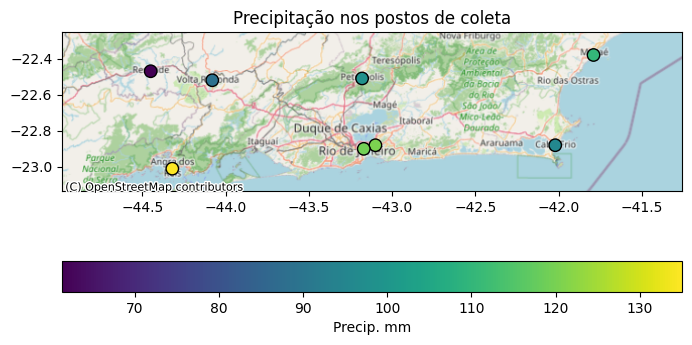

In [88]:
# Plot the GeoDataFrame with an OSM background
ax2 = gdf.plot(figsize=(8, 6), column='precip_jan_mm',
               edgecolor="black", markersize=80, legend=True,
               legend_kwds={"label": "Precip. mm", "orientation": "horizontal"})

ax2.set_title("Precipitação nos postos de coleta")
ax2.margins(0.2)

cx.add_basemap(ax2, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)

### **4.7 Exemplo: Aplicação da iterpolação em raster**

**Dataset de referência:** Será usado o dataset raster sintético, onde temos regiões sem valores, a qual queremos estimar e completar.

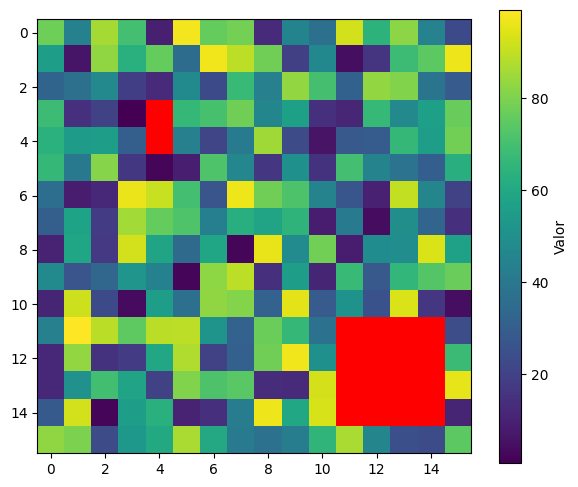

Shape: (16, 16)
NaNs totais: 18


In [89]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Criar raster 16x16
rng = np.random.default_rng(seed=42)
raster = rng.uniform(low=0.0, high=100.0, size=(16, 16))

# Região 1 de NaN — canto superior esquerdo
raster[3:5, 4:5] = np.nan

# Região 2 de NaN — canto inferior direito
raster[11:15, 11:15] = np.nan

# Visualizar
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='red')   # NaN aparece em vermelho

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(raster, cmap=cmap, interpolation='nearest')
plt.colorbar(im, ax=ax, label='Valor')
plt.tight_layout()
plt.show()

# Verificar
print("Shape:", raster.shape)
print("NaNs totais:", np.isnan(raster).sum())  # deve ser 32 (4x4 + 4x4)

**1º tipo:** Completar com a média global

Média global usada no preenchimento: 50.39


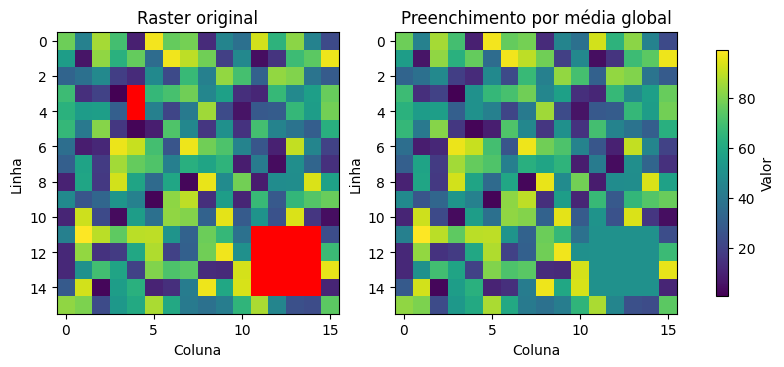

In [90]:
raster_media_global = raster.copy()
mascara_nan = np.isnan(raster)

############ MILK ############
media_global = np.nanmean(raster)
raster_media_global[mascara_nan] = media_global
############ FIM ############

print(f"Média global usada no preenchimento: {media_global:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(raster, cmap=cmap, interpolation="nearest")
axes[0].set_title("Raster original")

im = axes[1].imshow(raster_media_global, cmap="viridis", interpolation="nearest")
axes[1].set_title("Preenchimento por média global")

for ax in axes:
    ax.set_xlabel("Coluna")
    ax.set_ylabel("Linha")

plt.colorbar(im, ax=axes, label="Valor", shrink=0.8)
plt.show()

**2º tipo:** Interpolação local por vizinhança

- definição do raio ao redor do pixel vazio (raio=1 $\rightarrow$ kernel 3x3);
- se não houver vizinhos válidos suficientes, a janela aumenta;
- quando encontra valores conhecidos, calcula a média local

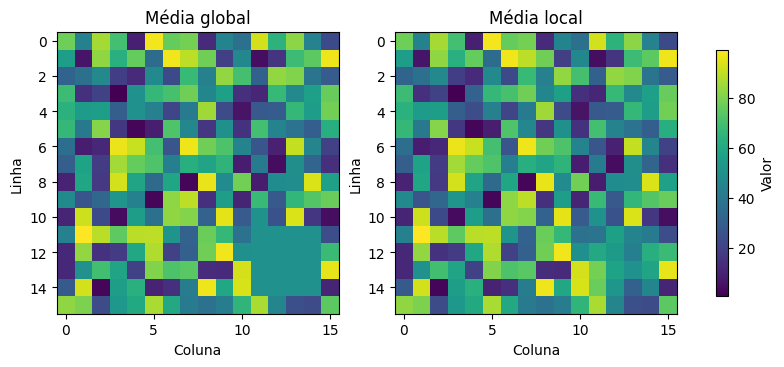

In [91]:
def interpolar_media_local(raster, raio_inicial=1, raio_maximo=5):
    raster_interpolado = raster.copy()
    linhas_nan, colunas_nan = np.where(np.isnan(raster))

    for linha, coluna in zip(linhas_nan, colunas_nan):
        valor_estimado = np.nan

        for raio in range(raio_inicial, raio_maximo + 1):
            linha_ini = max(0, linha - raio)
            linha_fim = min(raster.shape[0], linha + raio + 1)
            coluna_ini = max(0, coluna - raio)
            coluna_fim = min(raster.shape[1], coluna + raio + 1)
            ############ MILK ############
            janela = raster[linha_ini:linha_fim, coluna_ini:coluna_fim]
            vizinhos_validos = janela[~np.isnan(janela)]

            if vizinhos_validos.size > 0:
                valor_estimado = vizinhos_validos.mean()
                break
            ############ FIM ############

        raster_interpolado[linha, coluna] = valor_estimado

    return raster_interpolado


raster_media_local = interpolar_media_local(raster)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(raster_media_global, cmap="viridis", interpolation="nearest")
axes[0].set_title("Média global")

im = axes[1].imshow(raster_media_local, cmap="viridis", interpolation="nearest")
axes[1].set_title("Média local")

for ax in axes:
    ax.set_xlabel("Coluna")
    ax.set_ylabel("Linha")

plt.colorbar(im, ax=axes, label="Valor", shrink=0.8)
plt.show()

**3º tipo:** Interpolação por IDW

- **definição do raio máximo de vizinhança** a ser considerada ao redor do pixel vazio, se assemelha a definir os $k$ vizinhos mais próximos;
- se não houver vizinhos válidos suficientes, considerar toda a imagem;
- quando encontra valores conhecidos, calcula o IDW

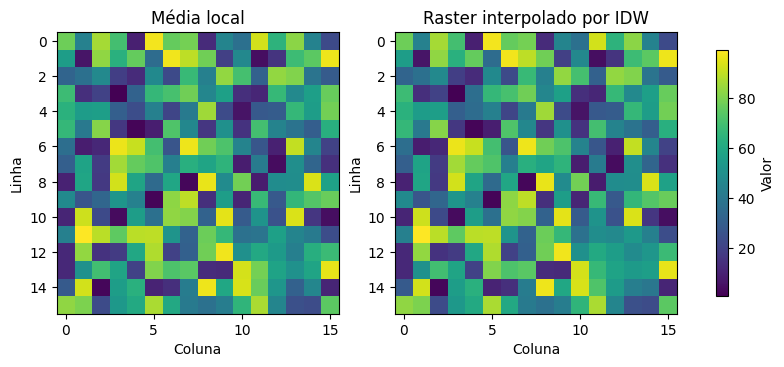

In [106]:
def interpolar_idw_raster(raster, potencia=2, raio_maximo=None):
    raster_interpolado = raster.copy()
    mascara_nan = np.isnan(raster)

    linhas_validas, colunas_validas = np.where(~mascara_nan)
    valores_validos = raster[linhas_validas, colunas_validas]

    linhas_nan, colunas_nan = np.where(mascara_nan)

    for linha, coluna in zip(linhas_nan, colunas_nan):
        distancias = np.sqrt((linhas_validas - linha) ** 2 + (colunas_validas - coluna) ** 2)

        if raio_maximo is not None:
            dentro_do_raio = distancias <= raio_maximo
            distancias_usadas = distancias[dentro_do_raio]
            valores_usados = valores_validos[dentro_do_raio]
        else:
            distancias_usadas = distancias
            valores_usados = valores_validos
        ############ MILK ############
        pesos = 1 / (distancias_usadas ** potencia)
        raster_interpolado[linha, coluna] = np.sum(pesos * valores_usados) / np.sum(pesos)
        ############ FIM ############
    return raster_interpolado


raster_idw = interpolar_idw_raster(raster, potencia=2, raio_maximo=3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(raster_media_local, cmap=cmap, interpolation="nearest")
axes[0].set_title("Média local")

im = axes[1].imshow(raster_idw, cmap="viridis", interpolation="nearest")
axes[1].set_title("Raster interpolado por IDW")

for ax in axes:
    ax.set_xlabel("Coluna")
    ax.set_ylabel("Linha")

plt.colorbar(im, ax=axes, label="Valor", shrink=0.8)
plt.show()

**Comparação**

In [93]:
linhas_nan, colunas_nan = np.where(mascara_nan)

comparacao_interpolacao = pd.DataFrame({
    "linha": linhas_nan,
    "coluna": colunas_nan,
    "media_global": raster_media_global[linhas_nan, colunas_nan],
    "media_local": raster_media_local[linhas_nan, colunas_nan],
    "idw": raster_idw[linhas_nan, colunas_nan],
})

comparacao_interpolacao.round(2)

,linha,coluna,media_global,media_local,idw
0,3,4,50.39,31.54,41.55
1,4,4,50.39,24.18,40.80
2,11,11,50.39,38.73,49.60
3,11,12,50.39,56.90,49.04
4,11,13,50.39,45.22,52.97
5,11,14,50.39,41.28,43.74
6,12,11,50.39,60.07,55.40
7,12,12,50.39,54.42,53.02
8,12,13,50.39,43.33,53.06
9,12,14,50.39,62.48,53.74


### **4.8 Completamento por modelo preditivo (inferência)**

O modo mais refinado de completamento, aqui está sendo colocado como um meio da ciência de dados, mas pode ser considerado o fim, a depender do problema.

Em geral, executa-se os seguintes passos:

- separar registros completos em treinamento (~60%) e teste (~40%);
- treinar um modelo com esses registros;
- aplicar o modelo nos registros de teste para verificação da qualidade;
- nos registros em que a variável-alvo está ausente, fazer a inferência.

> Falar em "treinar um modelo" soa fácil, mas existe neste ponto infinitas possibilidades.

### **4.9 Exemplo: Aplicação da iterpolação por modelo preditivo**

**Dataset de referência:** Será um o conjunto de dados [Diabetes](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) com 442 elementos dos quais 10 colunas de atributos do paciente e 1 da medida da progressão da doença.


In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes()
# Convert to DataFrame for easier viewing
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

df.tail()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


**1º Passo:** Separação em treino e teste

In [118]:
from sklearn.model_selection import train_test_split

df_treino, df_teste = train_test_split(df, test_size=0.4, random_state=42)

print("Treino:", df_treino.shape)
print("Teste:", df_teste.shape)

Treino: (265, 11)
Teste: (177, 11)


**2º Passo:** Separação em atributos (X) e alvo (Y)

In [130]:
df_treino_X, df_treino_Y = df_treino.iloc[:, :-1], df_treino.iloc[:, -1:]
df_teste_X, df_teste_Y = df_teste.iloc[:, :-1], df_teste.iloc[:, -1:]

X_treino, Y_treino = df_treino_X.values, df_treino_Y.values
X_teste, Y_teste = df_teste_X.values, df_teste_Y.values

print("X treino:", X_treino.shape)
print("Y treino:", Y_treino.shape)
print("X teste:", X_teste.shape)
print("Y teste:", Y_teste.shape)


X treino: (265, 10)
Y treino: (265, 1)
X teste: (177, 10)
Y teste: (177, 1)


**3º Passo:** Definição do modelo e treino

In [ ]:
from sklearn.linear_model import LinearRegression

# Definicao do modelo
# A regressao linear aprende uma relacao entre os atributos X
# e a variavel alvo Y.
modelo = LinearRegression()

# Treinamento
modelo.fit(X_treino, Y_treino)

print("Modelo treinado:", modelo)
print("Quantidade de coeficientes:", len(modelo.coef_[0]))

Modelo treinado: LinearRegression()
Quantidade de coeficientes: 10


**4º Passo:** Teste

In [136]:
# Predicao
Y_predito = modelo.predict(X_teste)

# Tabela comparando valor real e valor previsto
comparacao_teste = pd.DataFrame({
    "Y_real": Y_teste.ravel(), "Y_predito": Y_predito.ravel(),
})

comparacao_teste["erro"] = comparacao_teste["Y_predito"] - comparacao_teste["Y_real"]

comparacao_teste.round(2).head(10)

,Y_real,Y_predito,erro
0,219.0,136.99,-82.01
1,70.0,181.29,111.29
2,202.0,131.40,-70.60
3,230.0,276.84,46.84
4,111.0,119.99,8.99
5,84.0,91.81,7.81
6,242.0,261.50,19.50
7,272.0,182.15,-89.85
8,94.0,81.08,-12.92
9,96.0,112.80,16.80


**5º Passo:** Verificação da qualidade

In [137]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metricas de avaliacao
print(f"MAE:  {mean_absolute_error(Y_teste, Y_predito):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_teste, Y_predito)):.2f}")
print(f"R2:   {r2_score(Y_teste, Y_predito):.2f}")

MAE:  42.50
RMSE: 53.23
R2:   0.52


**6º Passo:** Melhorar...

## Lista de exercícios suplementares

**Exercício S1.** Faça o download de uma carta vetorial do BDGEx e realize a validação geométrica através das ferramentas nativas do QGIS (`qgis_process native:checkgeometry`), dando preferência pela interface CLI.

**Exercício S2.** Considere o raster sintético abaixo e realize a reamostragem pelas abordagens indicadas:

$$\begin{bmatrix}
12 & 14 & \text{NoData} & 18 & 20 \\
11 & \text{NoData} & 15 & 19 & 21 \\
10 & 12 & 16 & \text{NoData} & 22 \\
9 & 11 & \text{NoData} & 17 & 20 \\
8 & 10 & 13 & 15 & \text{NoData}
\end{bmatrix}$$

- **(a)** reamostragem/interpolação bilinear;
- **(b)** interpolação por IDW, adotando potência $p=2$;
- **(c)** Compare e discuta os dois métodos acima;
- **(d)** Realize os cálculos manualemente;
- **(e)** Transforme a tabela acima em raster e realize os cálculos por alguma ferramenta de processamento do QGIS, dando preferência pela interface CLI:

In [ ]:
!"{qgis_bin_path}qgis_process-qgis-ltr.bat" list

Available algorithms

QGIS (3D)
	3d:tessellate	Tessellate

GDAL
	gdal:aspect	Aspect
	gdal:assignprojection	Assign projection
	gdal:buffervectors	Buffer vectors
	gdal:buildvirtualraster	Build virtual raster
	gdal:buildvirtualvector	Build virtual vector
	gdal:cliprasterbyextent	Clip raster by extent
	gdal:cliprasterbymasklayer	Clip raster by mask layer
	gdal:clipvectorbyextent	Clip vector by extent
	gdal:clipvectorbypolygon	Clip vector by mask layer
	gdal:colorrelief	Color relief
	gdal:contour	Contour
	gdal:contour_polygon	Contour Polygons
	gdal:convertformat	Convert format
	gdal:dissolve	Dissolve
	gdal:executesql	Execute SQL
	gdal:extractprojection	Extract projection
	gdal:fillnodata	Fill NoData
	gdal:gdal2tiles	gdal2tiles
	gdal:gdal2xyz	gdal2xyz
	gdal:gdalinfo	Raster information
	gdal:gridaverage	Grid (Moving average)
	gdal:griddatametrics	Grid (Data metrics)
	gdal:gridinversedistance	Grid (Inverse distance to a power)
	gdal:gridinversedistancenearestneighbor	Grid (IDW with nearest nei

<!-- Tansformação afim:
$$\mathbf{x} = R\mathbf{u} + \mathbf{t}$$
$$
\begin{bmatrix} x_i \\ y_i \end{bmatrix} = \begin{bmatrix} a & b \\ c & d \end{bmatrix}\begin{bmatrix} u_i \\ v_i \end{bmatrix} + \begin{bmatrix} t_x \\ t_y \end{bmatrix}  
$$

Equações:

$$
\begin{cases}
x_1 = au_1+vv_1+t_x \\
y_1 = cu_1+dv_1+t_y \\
\ \ \vdots \\
x_n = au_n+vv_n+t_x \\
y_n = cu_n+dv_n+t_y \\
\end{cases}
$$

Isolando os parâmetros $X = [a,b,t_x,c,d,t_y]$ na forma $AX=L_b$:

$$ \begin{bmatrix}
u_1 & v_1 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & u_1 & v_1 & 1 \\
u_2 & v_2 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & u_2 & v_2 & 1 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
u_n & v_n & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & u_n & v_n & 1
\end{bmatrix}_{2n \times  6}
\begin{bmatrix}
a \\ b \\ t_x \\ c \\ d \\ t_y
\end{bmatrix}_{6 \times 1} =
\begin{bmatrix}
x_1 \\ y_1 \\ x_2 \\ y_2 \\ \vdots \\ x_n \\ y_n
\end{bmatrix}_{2n \times 1} $$

Ajustamento MMQ:

$$AX_a=L_a=L_b+V$$

Somatório do quadrado os resíduos deve ser minimizado:

$$V^TV = (AX_a - L_b)^T(AX_a - L_b)$$
$$=(X_a^TA^T - L_b^T)(AX_a - L_b)$$
$$=X_a^TA^TAX_a  - X_a^TA^TL_b -  L_b^TAX_a + L_bL_b = mín$$

Derivada igualada a zero:
$$ \frac{\partial V^TV}{\partial X} = 0 $$
$$ 2A^TAX_a - 2A^TL_b = 0$$
$$ X_a = (A^TA)^{-1} A^T L_b $$ -->